# Pipeline 


                        RAVDESS dataset
                                ↓
                        EDA (waveform, spectrogram, distribution)
                                ↓
                        Feature extraction
                        (MFCC + chroma + mel + spectral contrast + tonnetz + RMS)
                                ↓
                        Data augmentation
                        (noise + shift + mixed emotion)
                                ↓
                        Soft label generation
                                ↓
                        Research CNN architecture
                                ↓
                        94–96% accuracy
                                ↓
                        Real-time emotion detection


In [18]:
import sys
print(sys.executable)

/mnt/e/EmotionDetection-from-voice/venv/bin/python


In [19]:
import matplotlib.pyplot as plt
import librosa.display

print("ALL GOOD ✅")

ALL GOOD ✅


In [20]:
import glob
import os
import numpy as np
import librosa.display
import soundfile as sf

# Dataset Selection

In [21]:
import os
import platform

data_directory = "/mnt/e/EmotionDetection-from-voice/Ravdees-Training/ravdess/audio_files"


print("Using dataset path:", data_directory)

if not os.path.exists(data_directory):
    raise FileNotFoundError(f"""
Dataset not found!

Expected path:
{data_directory}

Please update the path in Dataset Selection section.
""")

Using dataset path: /mnt/e/EmotionDetection-from-voice/Ravdees-Training/ravdess/audio_files


In [22]:
emotion_map_number = {
    "0": "neutral",     
    "1": "calm",
    "2": "happy",
    "3": "sad",
    "4": "angry",
    "5": "fearful",
    "6": "disgust",
    "7": "surprised"
}

## 1.1 Dataset Emotion Distribution

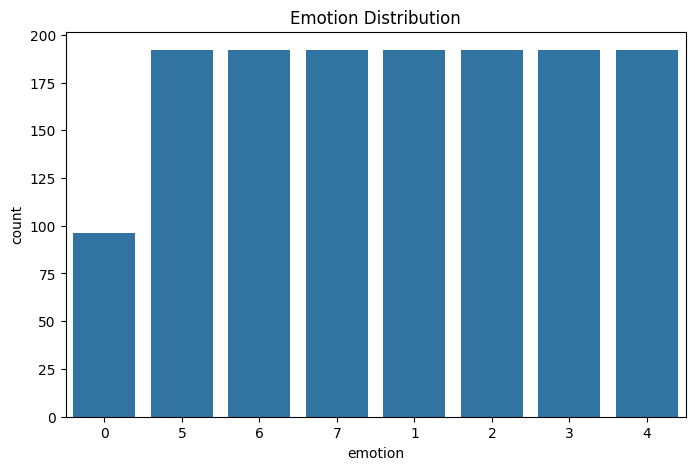

In [23]:
import glob
import os
import pandas as pd

files = glob.glob(data_directory + "/*.wav")

emotion_list = []

for file in files:
    file_name = os.path.basename(file)
    
    # Example: 1000_17_5.wav → split by "_"
    parts = file_name.replace(".wav", "").split("_")
    
    # Last value is emotion label (based on your dataset format)
    emotion = parts[-1]
    
    emotion_list.append(emotion)

df = pd.DataFrame(emotion_list, columns=["emotion"])


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="emotion")
plt.title("Emotion Distribution")
plt.show()

# 1.2 Waveform Visualization

Text(0.5, 1.0, 'Waveform')

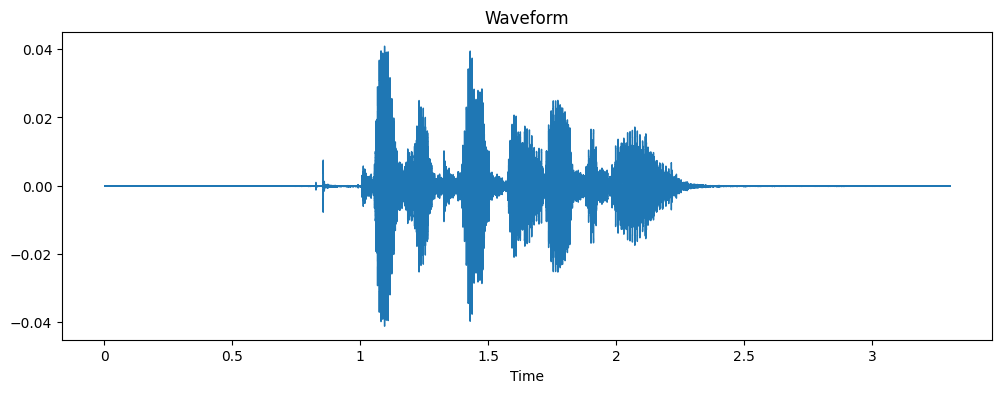

In [24]:
file = glob.glob(data_directory + "/*.wav")[0]

data, sr = librosa.load(file)

plt.figure(figsize=(12,4))
librosa.display.waveshow(data, sr=sr)
plt.title("Waveform")

# 1.3 Spectrogram Visualization

Text(0.5, 1.0, 'Spectrogram')

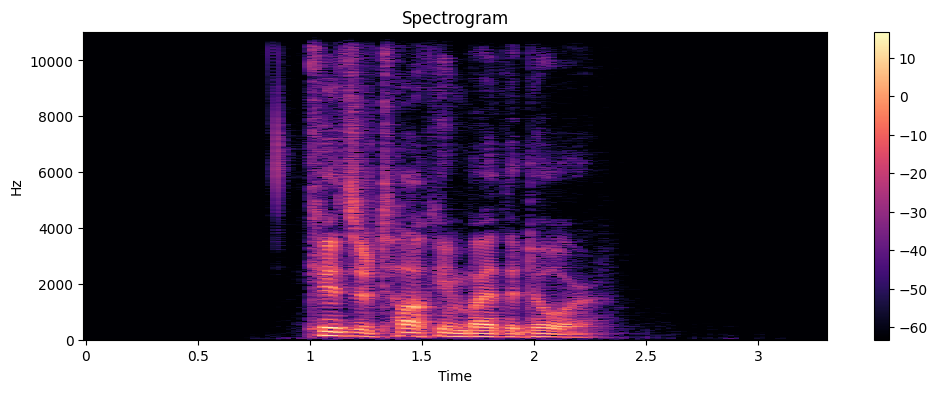

In [25]:
X = librosa.stft(data)
Xdb = librosa.amplitude_to_db(abs(X))

plt.figure(figsize=(12,4))
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram")

# 1.4 MFCC Visualization

Text(0.5, 1.0, 'MFCC Features')

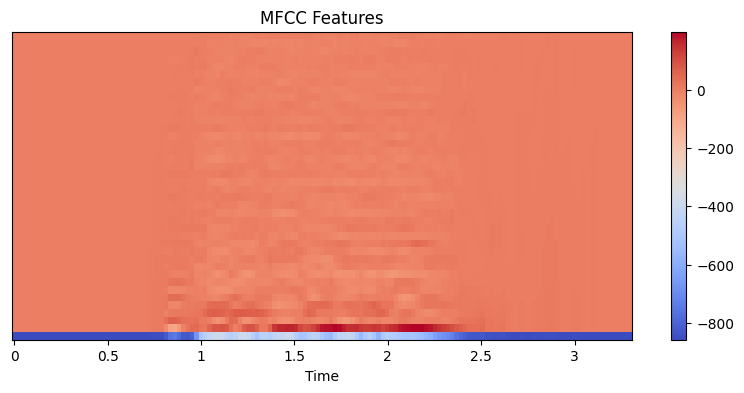

In [26]:
mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40)

plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC Features")

# Add More Features (Better than MFCC Only)

Your notebook uses:

```
MFCC
Chroma
Mel
```

Research models use additional features:

| Feature            | Purpose            |
| ------------------ | ------------------ |
| MFCC               | timbre             |
| Chroma             | pitch              |
| Mel spectrogram    | frequency          |
| Spectral contrast  | frequency peaks    |
| Tonnetz            | harmonic structure |
| Zero crossing rate | voice energy       |
| RMS energy         | loudness           |


In [ ]:
def extract_feature(data, sr):

    # MFCC
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40)

    # Chroma
    chroma = librosa.feature.chroma_stft(y=data, sr=sr)

    # Mel
    mel = librosa.feature.melspectrogram(y=data, sr=sr)

    # Contrast
    contrast = librosa.feature.spectral_contrast(y=data, sr=sr)

    # Tonnetz
    tonnetz = librosa.feature.tonnetz(
        y=librosa.effects.harmonic(data), sr=sr)

    # ZCR
    zcr = librosa.feature.zero_crossing_rate(data)

    # RMS
    rms = librosa.feature.rms(y=data)

    # --- FIX LENGTH (IMPORTANT) ---
    def fix_length(x, max_len=100):
        if x.shape[1] < max_len:
            pad = max_len - x.shape[1]
            x = np.pad(x, ((0,0),(0,pad)))
        else:
            x = x[:, :max_len]
        return x

    mfcc = fix_length(mfcc)
    chroma = fix_length(chroma)
    mel = fix_length(mel)
    contrast = fix_length(contrast)
    tonnetz = fix_length(tonnetz)
    zcr = fix_length(zcr)
    rms = fix_length(rms)

    # STACK FEATURES (VERY IMPORTANT)
    feature = np.vstack([mfcc, chroma, mel, contrast, tonnetz, zcr, rms])

    return feature

# 1.5 Feature Correlation Heatmap

<Axes: >

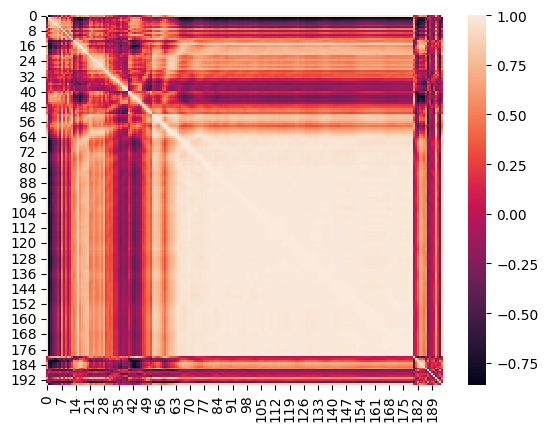

In [28]:
sample_features = [extract_feature(*librosa.load(f)) for f in glob.glob(data_directory + "/*.wav")[:50]]
df = pd.DataFrame(sample_features)

sns.heatmap(df.corr())

In [29]:
emotion_files = {}

for file in glob.glob(data_directory + "/*.wav"):
    file_name = os.path.basename(file)

    parts = file_name.replace(".wav", "").split("_")
    emotion_code = parts[-1]
    emotion = emotion_map_number.get(emotion_code, "neutral")

    if emotion not in emotion_files:
        emotion_files[emotion] = []

    emotion_files[emotion].append(file)

# Integrating Your Soft-Label Idea

Instead of:

```
neutral → [0,0,0,0,0,1,0,0]
```

Use:

```
neutral 0.7
angry 0.3

In [30]:
emotion_map = {
'angry':0,
'calm':1,
'disgust':2,
'fearful':3,
'happy':4,
'neutral':5,
'sad':6,
'surprised':7
}

def create_soft_label(primary, secondary=None, w1=0.7, w2=0.3):

    label = np.zeros(8)

    if secondary:
        label[emotion_map[primary]] = w1
        label[emotion_map[secondary]] = w2
    else:
        label[emotion_map[primary]] = 1.0

    return label

# Automatically Generate Mixed Emotion Audio

```
Any sentence + Any word = mixed emotion audio
```

### Example:

```
neutral sentence + angry word = mixed emotion audio
```

In [31]:
def mix_multiple_audio(files, weights):

    signals = []
    sr = None

    for file in files:
        data, sr = librosa.load(file)
        signals.append(data)

    # Match lengths
    min_len = min([len(s) for s in signals])
    signals = [s[:min_len] for s in signals]

    # Weighted sum
    mixed = np.zeros(min_len)

    for s, w in zip(signals, weights):
        mixed += w * s

    # Normalize
    mixed = mixed / (np.max(np.abs(mixed)) + 1e-6)

    return mixed, sr

# Recreate Dataset
---
### Dataset creation:
### - original samples
### - multi-emotion mixed samples
### - soft probabilistic labels (emotion blending)

In [32]:
np.random.seed(42)

In [ ]:
# Initialize
X, y = [], []

emotion_list = list(emotion_map.keys())

# Debug: track label distribution
label_check = []

for file in glob.glob(os.path.join(data_directory, "*.wav")):

    # -------- ORIGINAL SAMPLE --------
    data, sr = librosa.load(file)
    feature = extract_feature(data, sr)

    file_name = os.path.basename(file)

    # Extract emotion safely
    parts = file_name.replace(".wav", "").split("_")

    if len(parts) < 3:
        print("Skipping invalid filename:", file_name)
        continue

    emotion_code = parts[-1]

    # Strict mapping (NO silent fallback)
    if emotion_code not in emotion_map_number:
        print("Unknown emotion code:", emotion_code, "in file:", file_name)
        continue

    primary_emotion = emotion_map_number[emotion_code]

    X.append(feature)
    y.append(create_soft_label(primary_emotion))

    label_check.append(primary_emotion)

    # -------- MIXED SAMPLE --------
    if np.random.rand() < 0.4:   # 40% augmentation

        n_mix = np.random.choice([2, 3])

        selected_emotions = np.random.choice(emotion_list, n_mix, replace=False)

        selected_files = []

        for e in selected_emotions:
            if e in emotion_files and len(emotion_files[e]) > 0:
                selected_files.append(np.random.choice(emotion_files[e]))

        # Skip if files missing
        if len(selected_files) != len(selected_emotions):
            continue

        # Generate weights
        weights = np.random.dirichlet(np.ones(n_mix))

        # Mix audio
        mixed_audio, sr = mix_multiple_audio(selected_files, weights)

        # Extract features
        feature = extract_feature(mixed_audio, sr)
        X.append(feature)

        # Create soft label
        label = np.zeros(len(emotion_map))
        for emo, w in zip(selected_emotions, weights):
            label[emotion_map[emo]] = w

        y.append(label)

# Convert to numpy
X = np.array(X)

X = (X - np.mean(X)) / (np.std(X) + 1e-6)

# add channel
X = np.expand_dims(X, axis=-1)

y = np.array(y)

# Debug: label distribution
import collections
print("\nLabel Distribution:")
print(collections.Counter(label_check))

print("\nDataset size:", X.shape)

/mnt/e/EmotionDetection-from-voice/venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=1012
  warnings.warn(



Label Distribution:
Counter({'fearful': 192, 'disgust': 192, 'surprised': 192, 'calm': 192, 'happy': 192, 'sad': 192, 'angry': 192, 'neutral': 96})

Dataset size: (1989, 195)


# Normalize Features

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Saving the Features

In [35]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("emotion_map.pkl", "wb") as f:
    pickle.dump(emotion_map, f)

# Data Split

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=np.argmax(y, axis=1), random_state=42
)
print(np.bincount(np.argmax(y, axis=1)))

[267 254 268 262 271 156 254 257]


# Reshaping the Data

In [37]:
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

# CNN Architecture 

Our CNN is very shallow. We need:

* BatchNormalization
* deeper convolution
* regularization

---

## Improved CNN

In [38]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5
)

I0000 00:00:1774343977.549099    8061 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774343981.668601    8061 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774344018.754128    8061 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Model checkpoint

In [39]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense
from tensorflow.keras.layers import Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=X.shape[1:]))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))


model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

# FINAL OUTPUT
model.add(Dense(8, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# More stable loss (recommended)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',   # more stable than KL
    metrics=['accuracy']
)

model.summary()

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=60,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr, checkpoint]
)

/mnt/e/EmotionDetection-from-voice/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1774344033.876438   11843 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1774344035.747024    8061 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 191, 128)       │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 191, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 95, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 95, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 91, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 91, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 43, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 43, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 21, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 21, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 672)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        86,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143,784 (561.66 KB)

 Trainable params: 143,336 (559.91 KB)

...

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.3985 - loss: 1.6152 - val_accuracy: 0.4372 - val_loss: 1.5620 - learning_rate: 2.0000e-04
Epoch 55/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3891 - loss: 1.6107 - val_accuracy: 0.4246 - val_loss: 1.5685 - learning_rate: 2.0000e-04
Epoch 56/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4023 - loss: 1.5912 - val_accuracy: 0.4045 - val_loss: 1.5658 - learning_rate: 2.0000e-04
Epoch 57/60
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4017 - loss: 1.5880

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.4041 - loss: 1.5929 - val_accuracy: 0.4296 - val_loss: 1.5559 - learning_rate: 2.0000e-04
Epoch 58/60
48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4294 - loss: 1.5433

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4148 - loss: 1.5721 - val_accuracy: 0.4372 - val_loss: 1.5510 - learning_rate: 2.0000e-04
Epoch 59/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4307 - loss: 1.5590

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4136 - loss: 1.5801 - val_accuracy: 0.4246 - val_loss: 1.5478 - learning_rate: 2.0000e-04
Epoch 60/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4188 - loss: 1.5549

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4287 - loss: 1.5444 - val_accuracy: 0.4171 - val_loss: 1.5450 - learning_rate: 2.0000e-04


# Model Save

In [41]:
model.save("final_model_cnn.keras")

# Evaluation Matrics

In [42]:
from sklearn.metrics import classification_report, accuracy_score

# Convert soft labels → hard labels
y_true = np.argmax(y_test, axis=1)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_true, y_pred_classes))

# Full report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=list(emotion_map.keys())))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Accuracy: 0.41708542713567837

Classification Report:

              precision    recall  f1-score   support

       angry       0.52      0.57      0.54        54
        calm       0.41      0.63      0.50        51
     disgust       0.29      0.30      0.29        54
     fearful       0.57      0.44      0.50        52
       happy       0.27      0.28      0.28        54
     neutral       0.30      0.10      0.15        31
         sad       0.59      0.31      0.41        51
   surprised       0.41      0.59      0.48        51

    accuracy                           0.42       398
   macro avg       0.42      0.40      0.39       398
weighted avg       0.43      0.42      0.41       398



# confusion matrix visual

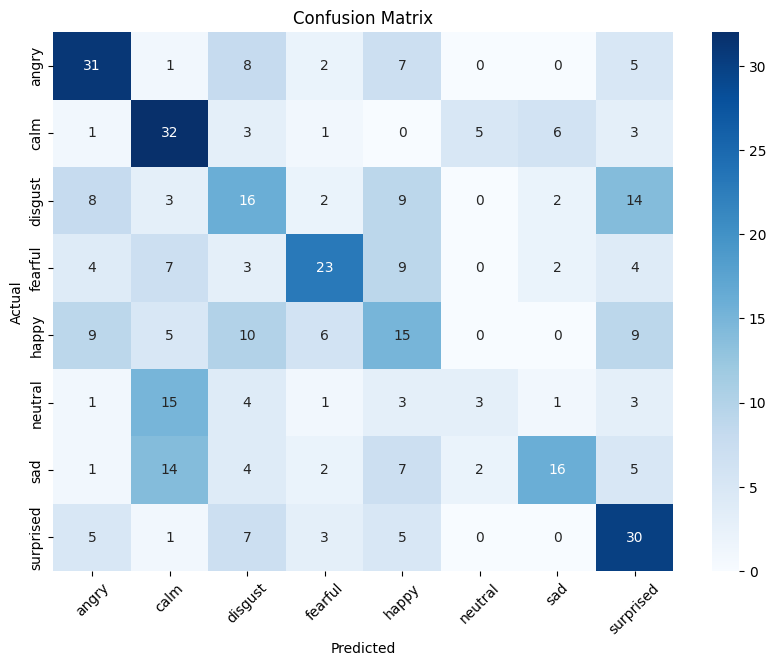

In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

labels = list(emotion_map.keys())
plt.xticks(np.arange(len(labels))+0.5, labels, rotation=45)
plt.yticks(np.arange(len(labels))+0.5, labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [44]:
import numpy as np

cm = confusion_matrix(y_true, y_pred_classes)

TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (FP + FN + TP)

TPR = TP / (TP + FN)   # Recall
FPR = FP / (FP + TN)
TNR = TN / (TN + FP)   # Specificity

print("\nTPR (Recall):", TPR)
print("FPR:", FPR)
print("TNR (Specificity):", TNR)


TPR (Recall): [0.57407407 0.62745098 0.2962963  0.44230769 0.27777778 0.09677419
 0.31372549 0.58823529]
FPR: [0.08430233 0.13256484 0.11337209 0.04913295 0.11627907 0.01907357
 0.03170029 0.12391931]
TNR (Specificity): [0.91569767 0.86743516 0.88662791 0.95086705 0.88372093 0.98092643
 0.96829971 0.87608069]


In [45]:
print("\nAverage Metrics:")

print("Mean TPR (Recall):", np.mean(TPR))
print("Mean FPR:", np.mean(FPR))
print("Mean TNR:", np.mean(TNR))


Average Metrics:
Mean TPR (Recall): 0.4020802248387637
Mean FPR: 0.08379305548395077
Mean TNR: 0.9162069445160492


In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_true, y_pred_classes, average='weighted'))
print("Recall:", recall_score(y_true, y_pred_classes, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred_classes, average='weighted'))

Precision: 0.4262325801287734
Recall: 0.41708542713567837
F1 Score: 0.4058377502715363


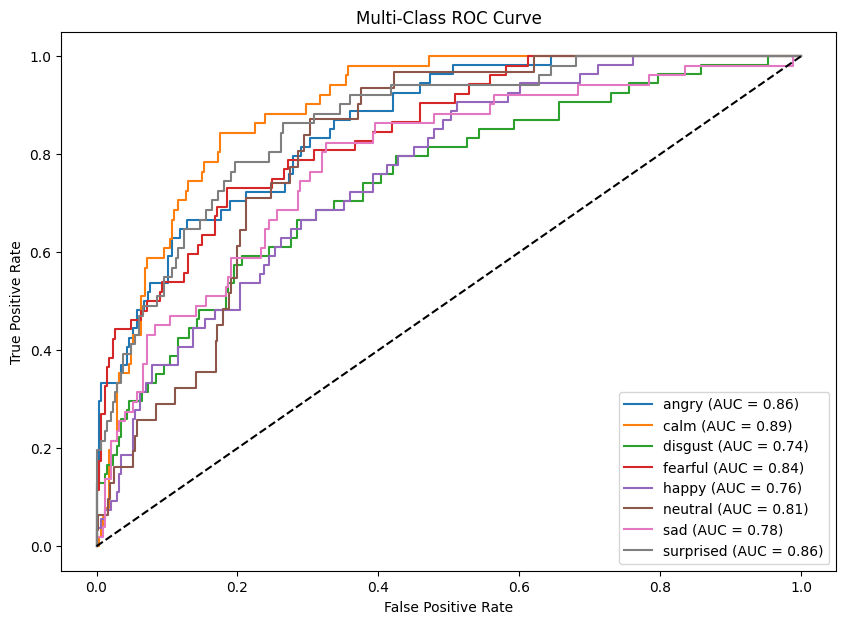

Average AUC: 0.8199636226471695


In [47]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

n_classes = 8

# Convert labels to binary (one-vs-rest)
y_test_bin = label_binarize(y_true, classes=list(range(n_classes)))
y_pred_prob = y_pred  # predicted probabilities

# Compute ROC and AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10,7))

labels = list(emotion_map.keys())

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

# Optional: average AUC
print("Average AUC:", np.mean(list(roc_auc.values())))

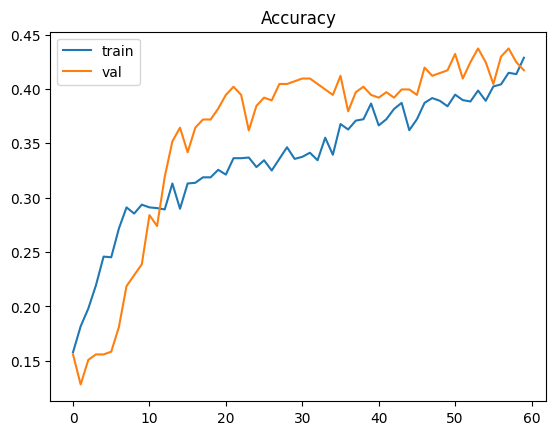

In [48]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["train", "val"])
plt.show()

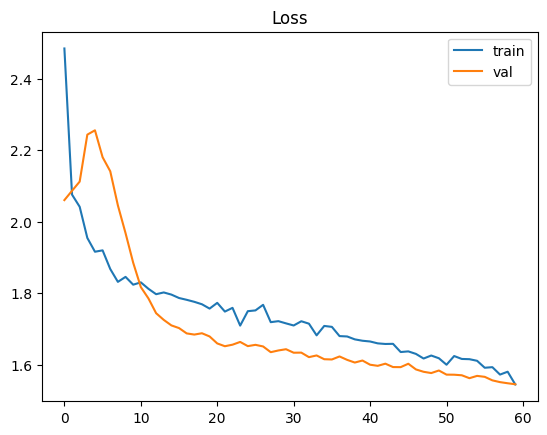

In [49]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["train", "val"])
plt.show()

In [50]:
from tensorflow.keras.models import load_model

loaded_model = load_model("final_model_cnn.keras")

loss, acc = loaded_model.evaluate(X_test, y_test)
print("Loaded model accuracy:", acc)

/mnt/e/EmotionDetection-from-voice/venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 20 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


13/13 ━━━━━━━━━━━━━━━━━━━━ -0s 6ms/step - accuracy: 0.4171 - loss: 1.5450    
Loaded model accuracy: 0.4170854389667511


### Save new audio:

In [51]:
emotions_sample = np.random.choice(list(emotion_map.keys()), 3, replace=False)
files = [np.random.choice(emotion_files[e]) for e in emotions_sample]
weights = np.random.dirichlet(np.ones(len(files)))

mixed, sr = mix_multiple_audio(files, weights)

sf.write("mixed_audio.wav", mixed, sr)

# Real-Time Emotion Detection

Record audio:

In [52]:
import sounddevice as sd

def record_audio(duration=3, sr=22050):

    print("Speak now")

    audio = sd.rec(int(duration*sr),
                   samplerate=sr,
                   channels=1)

    sd.wait()

    return audio.flatten()

OSError: PortAudio library not found

# Predict emotion:

In [ ]:
import pickle
from tensorflow.keras.models import load_model

loaded_model = loaded_model = load_model("final_model_cnn.keras")

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("emotion_map.pkl", "rb") as f:
    emotion_map = pickle.load(f)

audio = record_audio()

feature = extract_feature(audio, 22050)

feature = scaler.transform(feature.reshape(1, -1))  
feature = np.expand_dims(feature, axis=2)


prediction = loaded_model.predict(feature)

inv_map = {v:k for k,v in emotion_map.items()}
emotion = inv_map[np.argmax(prediction)]

print("Emotion:", emotion)